In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📚 1. Import Required Libraries


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import pickle
import joblib

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Input,
    LSTM
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
)

from tensorflow.keras import backend as K

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

## 💾 2. Load Preprocessed Datasets


In [3]:
X_train = np.load(
    '/content/drive/MyDrive/IDS_Project/data/X_train.npy'
)

y_train = np.load(
    '/content/drive/MyDrive/IDS_Project/data/y_train.npy'
)

X_test = np.load(
    '/content/drive/MyDrive/IDS_Project/data/X_test.npy'
)

y_test = np.load(
    '/content/drive/MyDrive/IDS_Project/data/y_test.npy'
)

In [4]:
label_encoder = joblib.load(
    '/content/drive/MyDrive/IDS_Project/data/label_encoder.pkl'
)

## 3. Reshape Features for CNN Input


In [7]:
X_train_cnn_lstm = X_train.reshape(
    (X_train.shape[0], X_train.shape[1], 1)
)

X_test_cnn_lstm = X_test.reshape(
    (X_test.shape[0], X_test.shape[1], 1)
)

## 🔀 4. Training and Validation Split

In [8]:
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(

    X_train_cnn_lstm,
    y_train,

    test_size=0.2,
    stratify=y_train,
    random_state=42

)

### CNN Architecture Implementation

In [ ]:
K.clear_session()

In [13]:
model_cnn_lstm = Sequential([

    Input(shape=(X_train_cnn_lstm.shape[1], 1)),

    Conv1D(
        filters=32,
        kernel_size=3,
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(0.2),

    LSTM(
        32
    ),

    Dropout(0.2),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        7,
        activation='softmax'
    )
])

In [15]:
model_cnn_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 27, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 27, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 27, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 27, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 13, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,447 (208.78 KB)

 Trainable params: 53,255 (208.03 KB)

 Non-trainable params: 192 (768.00 B)

## ⚙️ 6. Model Compilation

In [16]:
model_cnn_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 📌 7. Training Strategy

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_cnn_lstm_model_7_classes.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

### Model Training

In [18]:
history = model_cnn_lstm.fit(

    X_train_sub,
    y_train_sub,

    validation_data=(
        X_val_sub,
        y_val_sub
    ),

    epochs=30,

    batch_size=64,

    callbacks=[
        early_stop,
        checkpoint
    ],

    verbose=1
)

Epoch 1/30
1708/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6604 - loss: 0.7080
Epoch 1: val_accuracy improved from None to 0.69895, saving model to best_cnn_lstm_model_7_classes.h5



Epoch 1: finished saving model to best_cnn_lstm_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.6883 - loss: 0.5856 - val_accuracy: 0.6990 - val_loss: 0.5225
Epoch 2/30
1709/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7033 - loss: 0.5270
Epoch 2: val_accuracy improved from 0.69895 to 0.70436, saving model to best_cnn_lstm_model_7_classes.h5



Epoch 2: finished saving model to best_cnn_lstm_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 58s 34ms/step - accuracy: 0.7035 - loss: 0.5250 - val_accuracy: 0.7044 - val_loss: 0.5223
Epoch 3/30
1708/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7047 - loss: 0.5199
Epoch 3: val_accuracy improved from 0.70436 to 0.71496, saving model to best_cnn_lstm_model_7_classes.h5



Epoch 3: finished saving model to best_cnn_lstm_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.7040 - loss: 0.5195 - val_accuracy: 0.7150 - val_loss: 0.5099
Epoch 4/30
1708/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7114 - loss: 0.5121
Epoch 4: val_accuracy did not improve from 0.71496
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - accuracy: 0.7096 - loss: 0.5141 - val_accuracy: 0.7048 - val_loss: 0.5180
Epoch 5/30
1708/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7120 - loss: 0.5103
Epoch 5: val_accuracy did not improve from 0.71496
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 57s 33ms/step - accuracy: 0.7098 - loss: 0.5109 - val_accuracy: 0.7097 - val_loss: 0.5081
Epoch 6/30
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7079 - loss: 0.5097
Epoch 6: val_accuracy did not improve from 0.71496
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 80s 32ms/step - accuracy: 0.7092 - loss: 0.5093 - val_accuracy: 0.7087 - val_loss: 0.5018
Epoch 7/30
1708/1710 ━━━━━━━


Epoch 10: finished saving model to best_cnn_lstm_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 57s 33ms/step - accuracy: 0.7106 - loss: 0.5048 - val_accuracy: 0.7158 - val_loss: 0.4968
Epoch 11/30
1709/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7093 - loss: 0.5043
Epoch 11: val_accuracy did not improve from 0.71577
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 80s 32ms/step - accuracy: 0.7110 - loss: 0.5037 - val_accuracy: 0.7100 - val_loss: 0.5253
Epoch 12/30
1709/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7126 - loss: 0.5018
Epoch 12: val_accuracy did not improve from 0.71577
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.7120 - loss: 0.5027 - val_accuracy: 0.7144 - val_loss: 0.5018
Epoch 13/30
1709/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7105 - loss: 0.5040
Epoch 13: val_accuracy did not improve from 0.71577
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 85s 34ms/step - accuracy: 0.7117 - loss: 0.5020 - val_accuracy: 0.7147 - val_loss: 0.5031
Epoch 14/30
1709/1710


Epoch 15: finished saving model to best_cnn_lstm_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 54s 31ms/step - accuracy: 0.7129 - loss: 0.5010 - val_accuracy: 0.7168 - val_loss: 0.4956
Epoch 16/30
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7130 - loss: 0.5014
Epoch 16: val_accuracy did not improve from 0.71676
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.7134 - loss: 0.5019 - val_accuracy: 0.7102 - val_loss: 0.5088
Epoch 17/30
1709/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7131 - loss: 0.4997
Epoch 17: val_accuracy did not improve from 0.71676
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 54s 32ms/step - accuracy: 0.7128 - loss: 0.5005 - val_accuracy: 0.7149 - val_loss: 0.5007
Epoch 18/30
1709/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7145 - loss: 0.4982
Epoch 18: val_accuracy did not improve from 0.71676
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.7146 - loss: 0.4993 - val_accuracy: 0.7142 - val_loss: 0.5044
Epoch 19/30
1710/1710


Epoch 20: finished saving model to best_cnn_lstm_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 87s 36ms/step - accuracy: 0.7125 - loss: 0.4978 - val_accuracy: 0.7171 - val_loss: 0.4950
Epoch 21/30
1709/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7150 - loss: 0.4958
Epoch 21: val_accuracy did not improve from 0.71712
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.7137 - loss: 0.4980 - val_accuracy: 0.7099 - val_loss: 0.4983
Epoch 22/30
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7141 - loss: 0.4967
Epoch 22: val_accuracy did not improve from 0.71712
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - accuracy: 0.7151 - loss: 0.4970 - val_accuracy: 0.7088 - val_loss: 0.5215
Epoch 23/30
1708/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7129 - loss: 0.4992
Epoch 23: val_accuracy did not improve from 0.71712
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 57s 33ms/step - accuracy: 0.7138 - loss: 0.4972 - val_accuracy: 0.7155 - val_loss: 0.5041
Epoch 24/30
1709/1710

## Model Evaluation

In [22]:
test_loss, test_acc = model_cnn_lstm.evaluate(
    X_test_cnn_lstm,
    y_test,
    verbose=0
)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.9137
Test Loss: 0.3783


## 🔮 Generating Predictions

In [25]:
y_pred_probs = model_cnn_lstm.predict(X_test_cnn_lstm)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

1268/1268 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step


## 10. Classification Performance

In [26]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

               precision    recall  f1-score   support

       BENIGN       0.99      0.98      0.99     10873
   DrDoS_LDAP       0.64      0.97      0.77       978
  DrDoS_MSSQL       0.29      0.11      0.16      1860
DrDoS_NetBIOS       0.02      0.06      0.02       503
    DrDoS_UDP       1.00      0.90      0.95      8602
          Syn       1.00      1.00      1.00     17297
      UDP-lag       0.27      0.45      0.34       455

     accuracy                           0.91     40568
    macro avg       0.60      0.64      0.60     40568
 weighted avg       0.93      0.91      0.92     40568



### Confusion Matrix Analysis

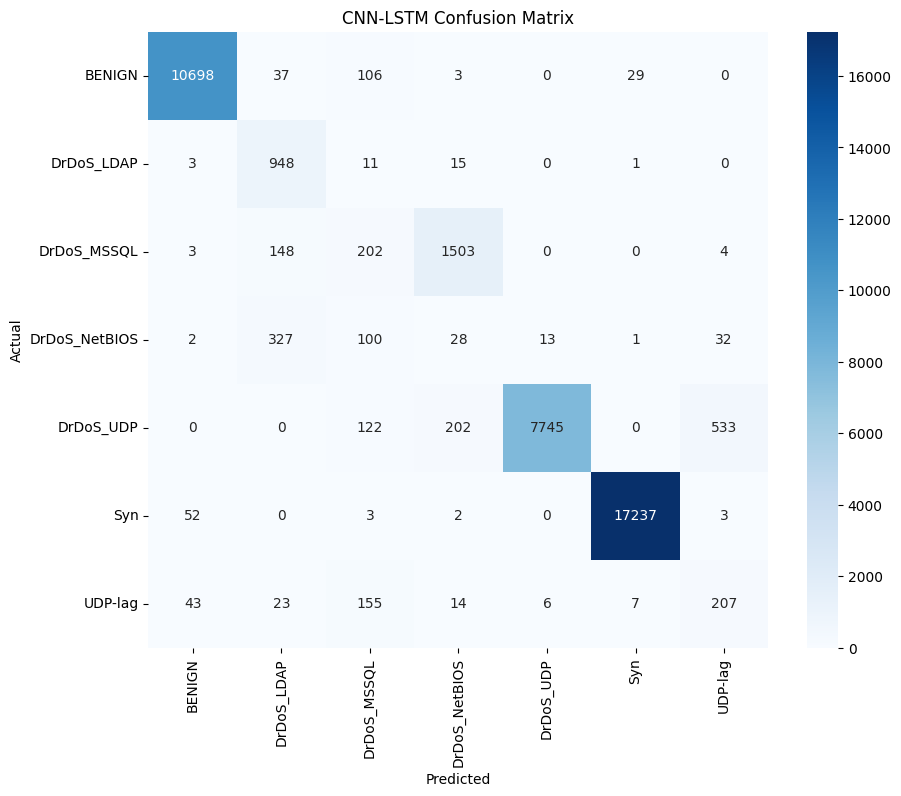

In [27]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('CNN-LSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Courbe Accuracy

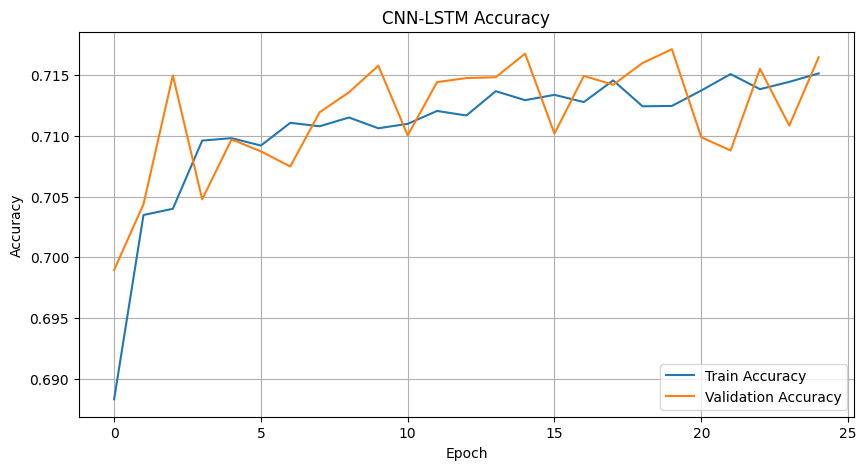

In [28]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('CNN-LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid()

plt.show()

## Courbe Loss

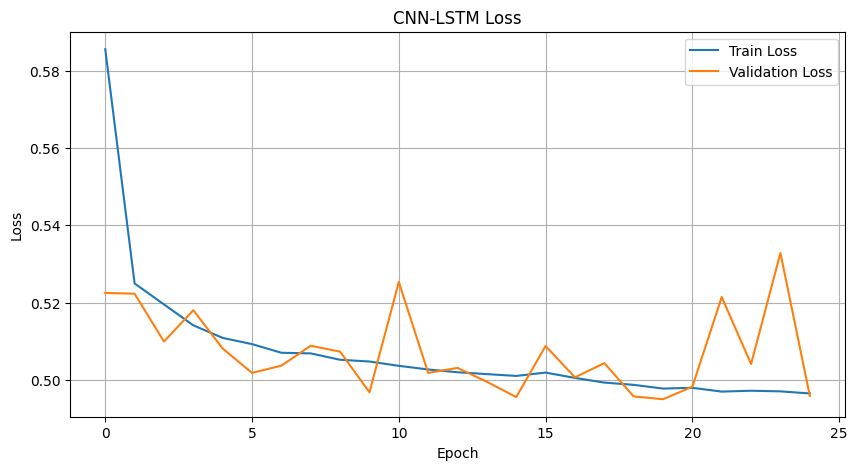

In [29]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('CNN-LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid()

plt.show()

## 💾 Saving the Trained Model


In [30]:
with open('CNN_LSTM_history.pkl', 'wb') as f:
    pickle.dump(
        history.history,
        f
    )

## Saving metrics

In [31]:
metrics = {
    'accuracy': test_acc,
    'loss': test_loss
}

with open('CNN_LSTM_metrics.pkl', 'wb') as f:
    pickle.dump(
        metrics,
        f
    )

## Saving predictions

In [32]:
np.save(
    'CNN_LSTM_pred.npy',
    y_pred
)